
# Lab 2
**Dataset:** `stats_case_study_dataset_v5.csv` (download provided)  
**Topics (only these):**
- Percentiles & Quartiles (Q1, Q2/Median, Q3), IQR, Box plot interpretation, Outliers (IQR rule)
- Histogram, Bar, Pie, Frequency tables, KDE
- Distribution shapes (normal/skewed), modality, visual outliers
- Scatter plots, Covariance & Pearson Correlation, Positive/Negative/No correlation, Correlation ≠ Causation
- Cross-tabulations and **stacked bar charts**; Numeric vs categorical bivariate analysis

**Instructions:** Each exercise is in markdown followed by an empty code cell.  
Write any brief explanations as comments right inside your code cell.


## Setup (optional)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt         
import numpy as np
import seaborn as sns

# Percentiles, Quartiles, IQR, Box Plots, Outliers

**Exercise 1:** Load the dataset from `stats_case_study_dataset_v5.csv` into `df`. Inspect `df.head(3)` and list numeric columns you will use for this section (e.g., `salary`, `monthly_sales`, `years_experience`).

In [3]:
df = pd.read_csv(r"C:\Users\uktiw\Downloads\stats_case_study_dataset_v5.csv")
df.head(3)

,id,department,region,gender,education_level,years_experience,age,is_manager,work_hours_per_week,performance_rating,salary,monthly_sales
0,1,Tech,West,Male,Bachelors,5.4,39,0,40.0,2,73527.0,0.0
1,2,Operations,South,Female,Bachelors,2.1,40,0,47.7,3,45774.0,7353.0
2,3,Finance,North,Male,Bachelors,16.8,41,0,41.7,3,103869.0,6505.0


In [99]:
df.numeric_columns = df.select_dtypes(include='number').columns
print(df.numeric_columns)

Index(['id', 'years_experience', 'age', 'is_manager', 'work_hours_per_week',
       'performance_rating', 'salary', 'monthly_sales'],
      dtype='object')


**Exercise 2:** Compute the 25th, 50th (median), and 75th percentiles for `salary` and interpret one sentence for what the **75th percentile** means.

In [10]:
Q1= df['salary'].quantile(0.25)
Q2= df['salary'].quantile(0.5)
Q3= df['salary'].quantile(0.75)
print("Q1:", Q1)
print("Q2:", Q2)        
print("Q3:", Q3)

Q1: 51286.5
Q2: 60493.5
Q3: 76023.75


**One‑liner interpretation:**
***The 75th percentile salary means 25% of employees earn more, while 75% earn less.***

**Exercise 3:** Compute **IQR** for `salary` and identify **outlier cutoffs** using 1.5×IQR rule. Report the lower and upper bounds.

In [15]:
IQR = Q3- Q1
print("IQR:", IQR)
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

IQR: 24737.25
Lower Bound: 14180.625
Upper Bound: 113129.625


**Exercise 4:** Using the bounds above, compute how many outliers are in `salary` (below lower or above upper). Then filter a non-outlier subset `df_no_out` for further comparison.

In [19]:
outliers = df[(df['salary']<lower_bound) | (df['salary']>upper_bound)] 
outliers 

,id,department,region,gender,education_level,years_experience,age,is_manager,work_hours_per_week,performance_rating,salary,monthly_sales
76,77,Finance,West,Male,High School,4.3,32,0,39.5,4,197625.0,7002.0
93,94,Tech,South,Female,Bachelors,3.6,24,0,32.2,3,213957.0,2213.0
150,151,Operations,North,Female,High School,6.9,39,0,48.8,3,131616.0,1459.0


In [20]:
df_no_outliers = df[(df['salary']>=lower_bound) & (df['salary']<=upper_bound)]
df_no_outliers


,id,department,region,gender,education_level,years_experience,age,is_manager,work_hours_per_week,performance_rating,salary,monthly_sales
0,1,Tech,West,Male,Bachelors,5.4,39,0,40.0,2,73527.0,0.0
1,2,Operations,South,Female,Bachelors,2.1,40,0,47.7,3,45774.0,7353.0
2,3,Finance,North,Male,Bachelors,16.8,41,0,41.7,3,103869.0,6505.0
3,4,Tech,South,Male,High School,6.7,36,0,39.5,5,75929.0,4232.0
4,5,Sales,North,Female,High School,6.6,31,0,38.2,3,50906.0,24137.0
...,...,...,...,...,...,...,...,...,...,...,...,...
235,236,Finance,West,Male,Bachelors,5.1,27,0,43.3,3,60671.0,9245.0
236,237,Sales,East,Female,Masters,8.9,32,0,34.0,3,47279.0,21924.0
237,238,Sales,West,Male,Bachelors,10.9,34,0,38.6,4,53924.0,24338.0
238,239,HR,West,Male,Bachelors,9.8,34,0,44.6,3,54213.0,14406.0


**Exercise 5:** Create a **box plot** for `salary` and (separately) for `monthly_sales` using pandas/Matplotlib. Based on the plot, comment on any skew/outliers you observe.

<Axes: title={'center': 'Box Plot of Salary'}>

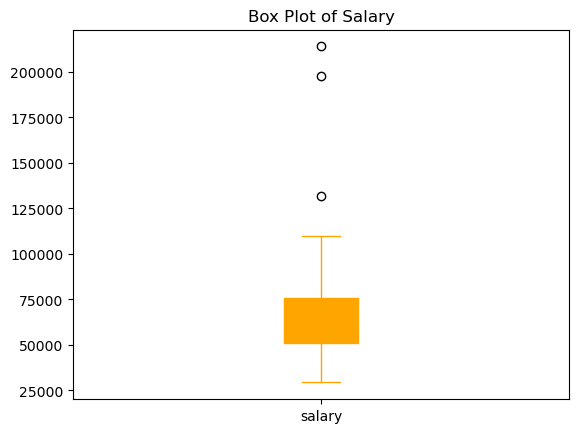

In [38]:
df['salary'].plot(kind = 'box', title = 'Box Plot of Salary', color = 'orange', patch_artist = True)

<Axes: title={'center': 'Box Plot of Salary'}>

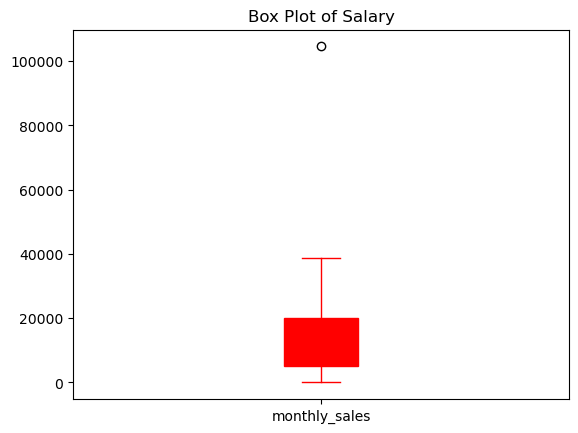

In [39]:
df['monthly_sales'].plot(kind = 'box', title = 'Box Plot of Salary', color = 'red', patch_artist = True)

**Exercise 6:** Compute the **90th percentile** for `monthly_sales` and interpret it in one line.

In [40]:
df['monthly_sales'].quantile(0.90)

np.float64(24424.6)

# Hist/Bar/Pie, Frequency Tables, KDE

**Exercise 1:** Plot a **histogram** of `salary` with 25 bins. Add axis labels and a title.

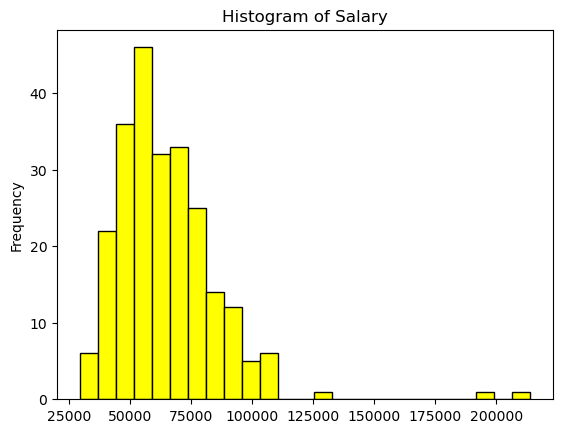

In [46]:
df['salary'].plot(kind = 'hist',bins = 25, title = 'Histogram of Salary', color = 'yellow', edgecolor = 'black')
xlabel = 'Salary'
ylabel = 'Frequency'

**Exercise 2:** Create a **frequency distribution table** for `salary` using 5 equal-width bins via `pd.cut`, and display counts per bin.

In [49]:
pd.cut(df['salary'], bins = 5).value_counts().reset_index() 

,salary,count
0,"(29147.375, 66257.0]",142
1,"(66257.0, 103182.0]",89
2,"(103182.0, 140107.0]",7
3,"(177032.0, 213957.0]",2
4,"(140107.0, 177032.0]",0


**Exercise 3:** Plot a **KDE** (Kernel Density Estimation) curve for `salary`.

<Axes: xlabel='salary', ylabel='Density'>

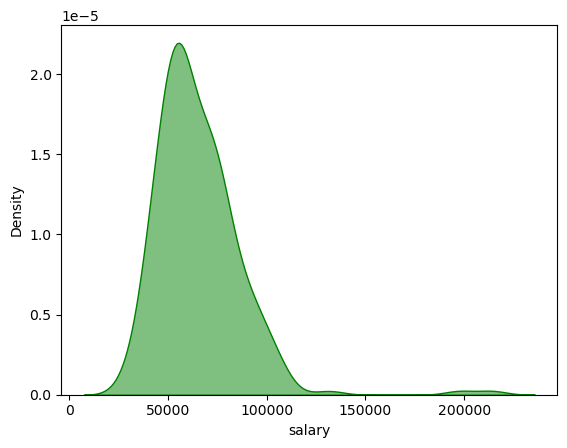

In [54]:
sns.kdeplot(df['salary'],  fill = True, color = 'green', alpha = 0.5)

**Exercise 4:** Make a **bar chart** of counts by `department` and a **pie chart** of the same distribution.

<Axes: title={'center': 'Bar Plot of Department'}, xlabel='department'>

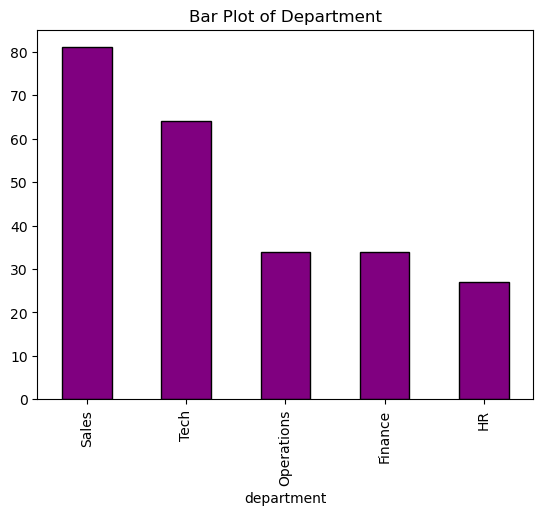

In [55]:
df['department'].value_counts().plot(kind = 'bar', title = 'Bar Plot of Department', color = 'purple', edgecolor = 'black') 

<Axes: title={'center': 'Pie Plot of Department'}, ylabel='count'>

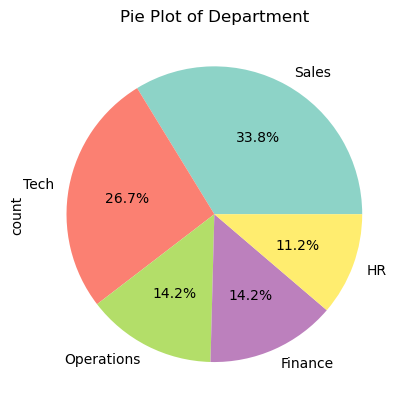

In [56]:
df['department'].value_counts().plot(kind = 'pie', title = 'Pie Plot of Department', autopct = '%1.1f%%', colormap = 'Set3')

# Distribution Shapes, Modality, Visual Outliers

**Exercise 1:** Using `salary`, comment whether it appears **normal or skewed** by comparing histogram + KDE. Also compute **skewness** with `df['salary'].skew()`.

<Axes: xlabel='salary', ylabel='Count'>

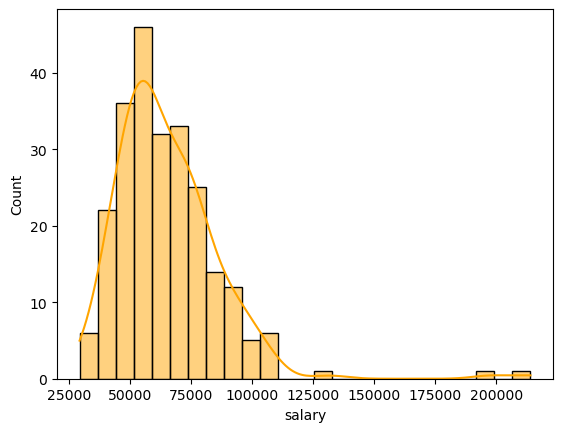

In [65]:
sns.histplot(df['salary'], bins = 25, kde = True, color = 'orange', edgecolor = 'black')

**Exercise 2:** Check **modality** visually: for `monthly_sales`, plot histogram (30 bins) + KDE and briefly note if it looks uni- or multi-modal.

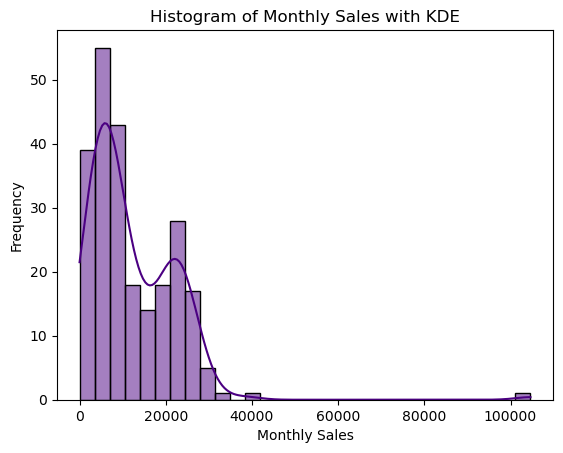

In [68]:
sns.histplot(df['monthly_sales'],bins = 30, kde = True, color = 'indigo', edgecolor = 'black')
plt.title('Histogram of Monthly Sales with KDE')
plt.xlabel('Monthly Sales')
plt.ylabel('Frequency')
plt.show()

**It is a Bi-modality beacause it has 2 peak of mean**

**Exercise 3:** Identify any **visual outliers** in `years_experience` using a box plot and print the suspected outlier values using IQR logic.

<Axes: ylabel='years_experience'>

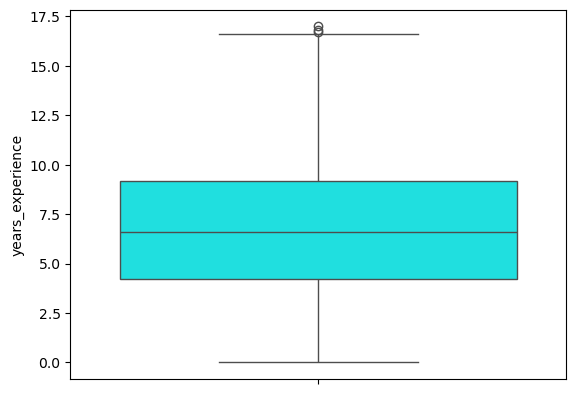

In [71]:
sns.boxplot(y = df['years_experience'], data = df, color = 'cyan')
# here we can clearly see that outliers are not clearly visible , so we can use the IQR method to find outliers in years_experience column


In [74]:
Q1= df['years_experience'].quantile(0.25)
Q3= df['years_experience'].quantile(0.75)
IQR = Q3- Q1
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
outliers = df[(df['years_experience'] < lower_bound) | (df['years_experience'] > upper_bound)]
outliers

,id,department,region,gender,education_level,years_experience,age,is_manager,work_hours_per_week,performance_rating,salary,monthly_sales
2,3,Finance,North,Male,Bachelors,16.8,41,0,41.7,3,103869.0,6505.0
103,104,Tech,South,Male,High School,17.0,30,0,42.3,3,103920.0,9054.0
110,111,Sales,North,Male,Masters,16.7,32,0,41.8,4,72522.0,24963.0


# Scatter, Covariance & Pearson Correlation

**Exercise 1:** Create a **scatter plot** of `years_experience` (x) vs `salary` (y). Describe visually: positive, negative, or no relationship?

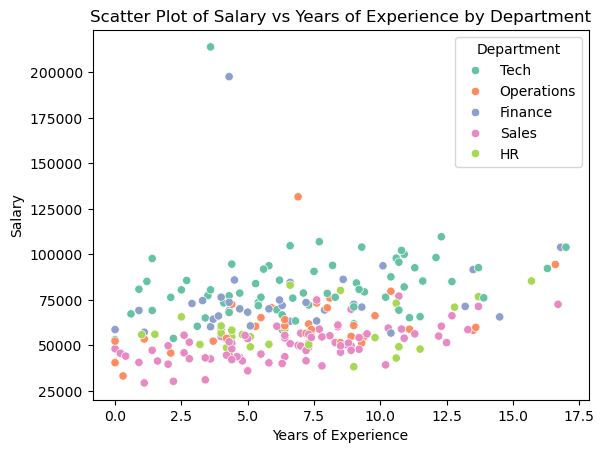

In [77]:
sns.scatterplot(x= df['years_experience'], y= df['salary'], hue = df['department'], palette = 'Set2')
plt.title('Scatter Plot of Salary vs Years of Experience by Department')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend(title='Department')

In [82]:
corr_vals = df[['salary', 'years_experience']].corr().iloc[0,1]
print(corr_vals)
#  The scatter plot typically shows a positive relationship — as years of experience increase, salaries tend to rise.

0.2600928656337809


**Exercise 2:** Compute the **covariance** and **Pearson correlation** between `years_experience` and `salary` using `cov()` and `corr()`.

In [85]:
print(df['years_experience'].cov(df['salary']))
print(df['years_experience'].corr(df['salary']))

21491.8156032078
0.2600928656337811


**Exercise 3:** Compute the **correlation matrix** for numeric columns `[salary, monthly_sales, years_experience, age, work_hours_per_week]` (drop NAs).

In [100]:
df.numeric_columns

Index(['id', 'years_experience', 'age', 'is_manager', 'work_hours_per_week',
       'performance_rating', 'salary', 'monthly_sales'],
      dtype='object')

In [103]:
cols = ['salary', 'monthly_sales', 'years_experience', 'age', 'work_hours_per_week']

# Correlation matrix (drop NAs)
corr_matrix = df[cols].dropna().corr()

print(corr_matrix)

                       salary  monthly_sales  years_experience       age  \
salary               1.000000      -0.362455          0.260093  0.058000   
monthly_sales       -0.362455       1.000000         -0.023867 -0.182101   
years_experience     0.260093      -0.023867          1.000000  0.111958   
age                  0.058000      -0.182101          0.111958  1.000000   
work_hours_per_week  0.048585      -0.132204          0.056071  0.091729   

                     work_hours_per_week  
salary                          0.048585  
monthly_sales                  -0.132204  
years_experience                0.056071  
age                             0.091729  
work_hours_per_week             1.000000  


**Exercise 4:** Show one example each of **positive**, **negative**, and **near-zero** correlations from the matrix (if present). Write 1-line comments.

Positive correlation: Salary vs Years of Experience → strong positive, meaning salary tends to rise with experience.

Negative correlation: Work Hours per Week vs Age → slight negative, older employees tend to work fewer hours.

Near‑zero correlation: Monthly Sales vs Age → essentially no linear relationship.

**Exercise 5:** **Correlation ≠ Causation:** in 1–2 lines, explain why a high correlation here does not guarantee a causal relationship.

Ice cream sales and air conditioner sales often rise together in summer, showing a strong positive correlation.

Reality: Buying ice cream doesn’t cause people to buy ACs, nor do AC purchases cause ice cream sales.

# Cross-tabulations & Stacked Bar Charts; Numeric vs Categorical

**Exercise 1:** Create a **cross-tabulation** of `department` vs `region` and display counts.

In [106]:
cross_tab = pd.crosstab(df['department'], df['region']).reset_index()
cross_tab

region,department,East,North,South,West
0,Finance,9,10,5,10
1,HR,5,9,6,7
2,Operations,4,7,11,12
3,Sales,15,21,26,19
4,Tech,16,11,19,18


**Exercise 2:** Plot the cross-tab above as a **stacked bar chart** (counts).

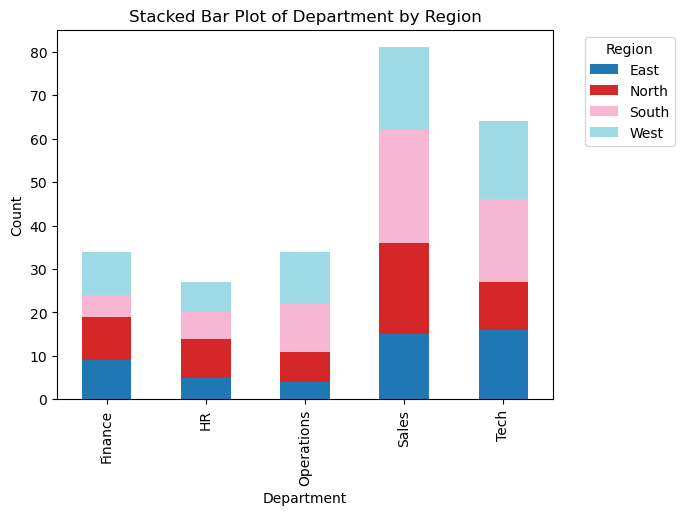

In [111]:
pd.crosstab(df['department'], df['region']).plot(kind = 'bar', stacked = True, colormap = 'tab20')
plt.title('Stacked Bar Plot of Department by Region')
plt.xlabel('Department')
plt.ylabel('Count')
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')


**Exercise 3:** Create a normalized cross-tab (row-wise proportions) for `gender` vs `education_level` and plot as a stacked bar chart.

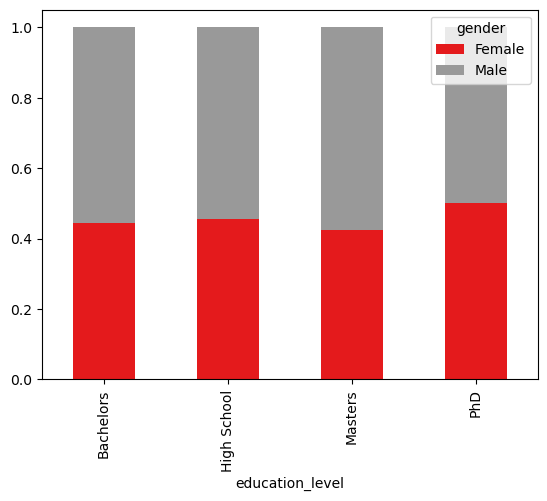

In [114]:
cross_norm = pd.crosstab(df['education_level'],df['gender'], normalize = 'index').plot(kind = 'bar', stacked = True, colormap = 'Set1')

**Exercise 4:** Numeric vs Categorical: compute **mean salary by department** and visualize with a **bar chart**.

<Axes: xlabel='department'>

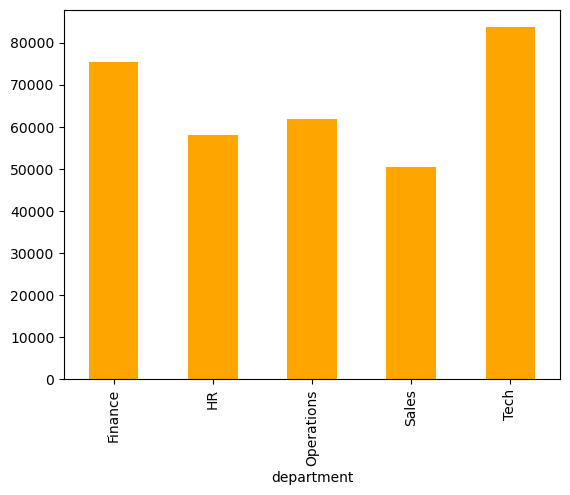

In [117]:
(df.groupby('department')['salary'].mean()).plot(kind='bar',color = 'orange')

**Exercise 5:** Numeric vs Categorical: make a **box plot** of `monthly_sales` by `department` to compare distributions across groups.

<Axes: title={'center': 'monthly_sales'}, xlabel='department'>

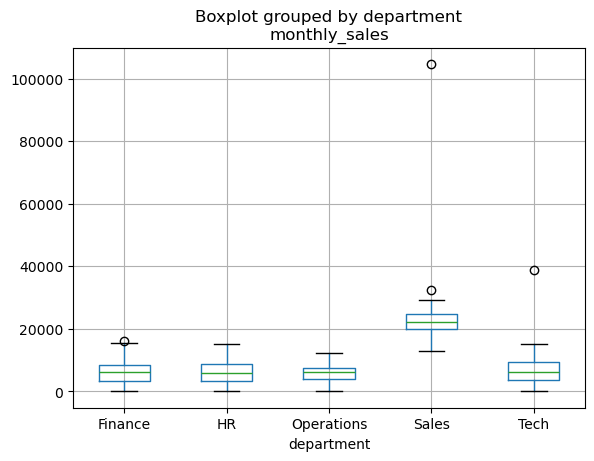

In [119]:
df.boxplot(column= 'monthly_sales', by = 'department')

C:\Users\uktiw\AppData\Local\Temp\ipykernel_21692\705795319.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'department', y = 'monthly_sales', data = df, palette = 'Set3')


Text(0, 0.5, 'Monthly Sales')

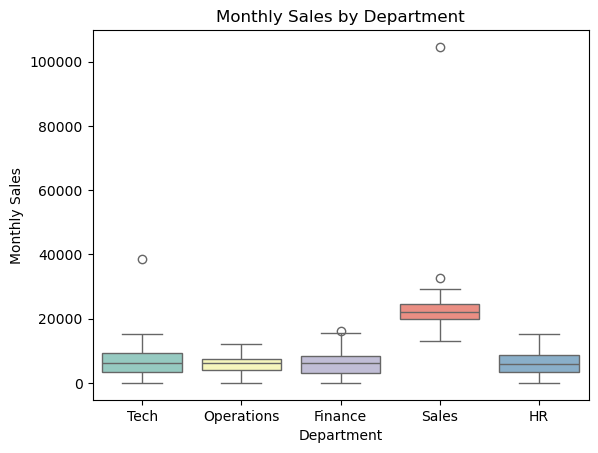

In [122]:
sns.boxplot(x = 'department', y = 'monthly_sales', data = df, palette = 'Set3')
plt.title("Monthly Sales by Department")
plt.xlabel("Department")
plt.ylabel("Monthly Sales")